In [3]:
#Import packages used
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import scipy.optimize
import matplotlib.ticker

import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

In [4]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmax*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmax
    sensGrad[specInd] = dMonodA*monodG*Vmax
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmax*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmax*monodG

    return impact

#Gradient of impact function (generates a matrix used in linear stability analysis)
def gradImpactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    nablaF = np.zeros((rs.shape[0],rs.shape[0]))
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2

    for i in range(len(rs)):
        if i == specInd: #If the impact is on the missing amino acid
            nablaF[i,i] = -(Vmax/Ys[i,i])*monodG*dMonodA
            nablaF[i,-1] = -(Vmax/Ys[i,i])*dMonodG*monodA
        elif i == len(rs)-1: #If the impact is on the glucose
            nablaF[i,specInd] = -(Vmax/Ys[specInd,i])*monodG*dMonodA
            nablaF[i,-1] = -(Vmax/Ys[specInd,i])*dMonodG*monodA - sum(Cs[specInd,:-1])*Vmax*dMonodG
        else: #If the impact is on any of the (potentially) secreted amino acids
            nablaF[i,-1] = Cs[specInd,i]*Vmax*dMonodG

    return(nablaF)

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In [5]:
#2-species function test
Kms = np.array([[0.8,-1,1.8],[-1,1.4,0.7]]) #Proline auxotroph then tryptophan auxotroph
Ys = np.array([[5,0,1],[0,10,1]])
Cs = np.array([[0,0.025,-1],[0.05,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Vmax = 0.4

EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

proConc = 0
tryConc = 0
        
rIn = np.array([proConc,tryConc,2])
sysParams = {'rIn':rIn}

DilRate = 0.01

In [9]:
#Generate interaction array and allogenic acceleration array for proline auxotroph
minG = 0
maxG = 3
minP = 0
maxP = 0.6

sampPtsG = 100
sampPtsP = 100

gList = np.linspace(minG,maxG,sampPtsG)
pList = np.linspace(minP,maxP,sampPtsP)

gField, pField = np.meshgrid(gList, pList)

gStep = gField[1,0] - gField[0,0]
pStep = pField[0,1] - pField[0,0]

impactsPonP = np.zeros((sampPtsG,sampPtsP,3))
impactsWonP = np.zeros((sampPtsG,sampPtsP,3))
sensGradsP = np.zeros((sampPtsG,sampPtsP,3))
PonP = np.zeros((sampPtsG,sampPtsP))
WonP = np.zeros((sampPtsG,sampPtsP))
sigP = np.zeros((sampPtsG,sampPtsP,3))
AAp = np.zeros((sampPtsG,sampPtsP))

for gInd in range(sampPtsG):
    for pInd in range(sampPtsP):
        r = np.array([pField[gInd,pInd],1,gField[gInd,pInd]])
        
        impactsPonP[gInd,pInd,:] = impactFunc(r,0,EOparams)
        impactsWonP[gInd,pInd,:] = impactFunc(r,1,EOparams)
        sensGradsP[gInd,pInd,:] = gradSensFunc(r,0,EOparams)
        
        PonP[gInd,pInd] = np.dot(impactsPonP[gInd,pInd,:],sensGradsP[gInd,pInd,:])
        WonP[gInd,pInd] = np.dot(impactsWonP[gInd,pInd,:],sensGradsP[gInd,pInd,:])
        
        sigP[gInd,pInd,:] = DilRate*(rIn-r)
        AAp[gInd,pInd] = np.dot(sigP[gInd,pInd,:],sensGradsP[gInd,pInd,:])

In [11]:
#Write functions that generates the E matrix (the environmental dissipation portion of the Jacobian) as well as the impaact and sensitivity gradient matrices 
def constructEmat(rs,xs,EOparams,D):
    Emat = np.zeros((rs.shape[0],rs.shape[0]))
    Emat -= np.identity(rs.shape[0])*D

    for beta in range(xs.shape[0]):
        Emat += gradImpactFunc(rs,beta,EOparams) * xs[beta]
    return(Emat)

def constructGmat(rs,xs,EOparams):
    Gmat = np.array([gradSensFunc(rs,alpha,EOparams)*xs[alpha] for alpha in range(len(xs))])
    return(Gmat)

def constructFmat(rs,xs,EOparams):
    Fmat = np.array([impactFunc(rs,beta,EOparams) for beta in range(len(xs))])
    return(Fmat.transpose())

def constructJacobian(rs,xs,EOparams,D):
    Emat = constructEmat(rs,xs,EOparams,D)
    Gmat = constructGmat(rs,xs,EOparams)
    Fmat = constructFmat(rs,xs,EOparams)
    Omat = np.zeros((len(xs),len(xs)))

    Jstar = np.block([[Omat,Gmat],[Fmat,Emat]])

    return(Jstar)

In [13]:
#Generate a chemostat model to get equilibrium r* at multiple leakage rates of the proline auxotroph
B0 = np.array([1,1])
noCs = 500

resList = np.zeros((noCs,3))
abunds = np.zeros((noCs,2))
eigs = np.zeros((noCs,5),dtype=np.complex_)
leakages = np.arange(0.01,noCs*0.0005+0.01,0.0005)

for i in range(noCs):
    Cs = np.array([[0,leakages[i],-1],[0.05,0,-1]])
    EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}
    
    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,20000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)
    chemSim.simEOmodel('Chemostat')
    
    resList[i,:] = chemSim.resTimeseries[:,-1]
    abunds[i,:] = chemSim.specTimeseries[:,-1]

    #This is the correct linear stability procedure for EO systems
    jac = constructJacobian(resList[i,:],abunds[i,:],EOparams,DilRate)
    [eigVals,eigVecs] = np.linalg.eig(jac)
    eigs[i,:] = eigVals

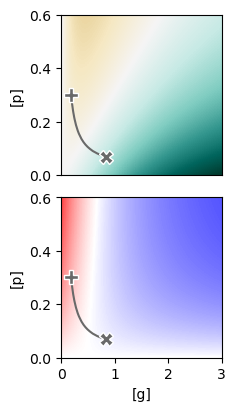

In [28]:
fig, axAr = plt.subplots(nrows = 2, ncols = 1, constrained_layout = True, figsize=(2.5,4))
ax1 = axAr[0]
ax2 = axAr[1]

cLim = 0.005

ax1.imshow(WonP,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax1.set_aspect(maxG/maxP)
ax1.set_xticks([], [])
ax1.set_ylabel('[p]')
ax1.set_xlim([0,maxG])
ax1.set_ylim([0,maxP])
ax1.plot(resList[:,2],resList[:,0],color='dimgray')
ax1.plot(resList[0,2],resList[0,0],'X',mfc='dimgray',mec='white',ms=10)
ax1.plot(resList[-1,2],resList[-1,0],'P',mfc='dimgray',mec='white',ms=10)
#ax1.plot(resList[int(noCs/2),2],resList[int(noCs/2),0],'s',mfc='dimgray',mec='white')

cLim = 0.001

ax2.imshow(AAp,cmap='bwr',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax2.set_aspect(maxG/maxP)
ax2.set_xlabel('[g]')
ax2.set_ylabel('[p]')
ax2.set_xlim([0,maxG])
ax2.set_ylim([0,maxP])
ax2.plot(resList[:,2],resList[:,0],color='dimgray')
ax2.plot(resList[0,2],resList[0,0],'X',mfc='dimgray',mec='white',ms=10)
ax2.plot(resList[-1,2],resList[-1,0],'P',mfc='dimgray',mec='white',ms=10)
#ax2.plot(resList[int(noCs/2),2],resList[int(noCs/2),0],'s',mfc='dimgray',mec='white')

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\2SpecAuxotrophSweepEnvironmentSpaces.pdf")

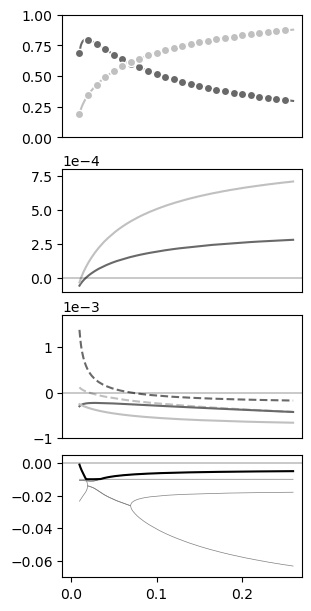

In [32]:
#Display plots of interactions, allogenic accelerations and abundances as function of leakage
fig, axAr = plt.subplots(nrows = 4, ncols = 1, constrained_layout = True, figsize=(3,6))
axAr[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axAr[2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

AAlist = np.zeros((noCs,2))
IntraList = np.zeros((noCs,2))
InterList = np.zeros((noCs,2))
predAbunds = np.zeros((noCs,2))

for i in range(noCs):
    Cs = np.array([[0,leakages[i],-1],[0.05,0,-1]])
    EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

    AAlist[i,0] = intrinsicGR(resList[i,:],0,EOparams,sysParams)
    AAlist[i,1] = intrinsicGR(resList[i,:],1,EOparams,sysParams)
    InterList[i,0] = instInteract(resList[i,:],0,1,EOparams) #Tryptophan auxotroph on proline auxotroph
    InterList[i,1] = instInteract(resList[i,:],1,0,EOparams) #Proline auxotroph on tryptophan auxotroph
    IntraList[i,0] = instInteract(resList[i,:],0,0,EOparams) #Proline auxotroph on itself
    IntraList[i,1] = instInteract(resList[i,:],1,1,EOparams) #Tryptophan auxotroph on itself

axAr[0].plot(leakages,abunds[:,0],color='dimgray')
axAr[0].plot(leakages,abunds[:,1],color='silver')

for i in range(noCs):
    A = np.array([[IntraList[i,0],InterList[i,0]],[InterList[i,1],IntraList[i,1]]])
    mu = AAlist[i,:]
    predAbunds[i,:] = -np.matmul(np.linalg.inv(A),mu)

axAr[0].plot(leakages[::20],predAbunds[::20,0],'o',mfc='dimgray',mec='white')
axAr[0].plot(leakages[::20],predAbunds[::20,1],'o',mfc='silver',mec='white')
axAr[0].set_xlim([-0.01,np.max(leakages)+0.01])
axAr[0].set_xticks([], [])
axAr[0].set_ylim([0,1])

axAr[1].plot(leakages,AAlist[:,0],color='dimgray')
axAr[1].plot(leakages,AAlist[:,1],color='silver')
axAr[1].plot([-0.1,1.1],[0,0],'k',linewidth=0.3)
axAr[1].set_ylim([-0.0001,0.0008])
axAr[1].set_xlim([-0.01,np.max(leakages)+0.01])
axAr[1].set_xticks([], [])

axAr[2].plot(leakages,InterList[:,0],'--',color='dimgray')
axAr[2].plot(leakages,InterList[:,1],'--',color='silver')
axAr[2].plot(leakages,IntraList[:,0],color='dimgray') #Proline auxtroph on itself
axAr[2].plot(leakages,IntraList[:,1],color='silver')
axAr[2].plot([-0.1,1.1],[0,0],'k',linewidth=0.3)
axAr[2].set_xlim([-0.01,np.max(leakages)+0.01])
axAr[2].set_ylim([-0.001,0.0017])
axAr[2].set_xticks([], [])

eigs.sort(axis=1)
axAr[3].plot(leakages,np.real(eigs),lw=0.5,color='gray')
axAr[3].plot(leakages,np.max(np.real(eigs),axis=1),'k')
axAr[3].plot([-0.1,1.1],[0,0],'k',linewidth=0.3)
axAr[3].set_xlim([-0.01,np.max(leakages)+0.01])
axAr[3].set_ylim([-0.07,0.005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\2SpecAuxotrophSweepCompositions.pdf")

In [14]:
eigsGLV = np.zeros((noCs,2),dtype=np.complex_)
for i in range(noCs):
    A = np.array([[IntraList[i,0],InterList[i,0]],[InterList[i,1],IntraList[i,1]]])
    mu = AAlist[i,:]
    
    jac = np.array([[predAbunds[i,j] * A[j,k] for j in range(2)] for k in range(2)]) 
    #jac = np.matmul(np.diag(predAbunds[i,:]),A)
    [eigVals,eigVecs] = np.linalg.eig(jac)
    eigsGLV[i,:] = eigVals

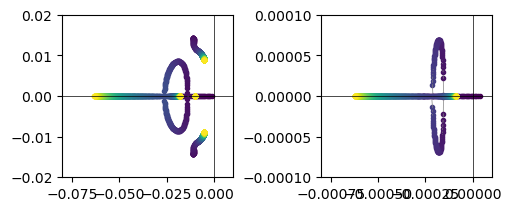

In [15]:
fig, axAr = plt.subplots(nrows = 1, ncols = 2, constrained_layout = True, figsize=(5,2))

cmap = plt.colormaps["viridis"]

eigs.sort(axis=1)
eigsGLV.sort(axis=1)

subSamp = 1
for i in range(int(noCs/subSamp)-1):
    currCol = cmap(i/(noCs/subSamp))
    axAr[0].plot(np.real(eigs[i*subSamp,:]),np.imag(eigs[i*subSamp,:]),'.',color=currCol)
    axAr[1].plot(np.real(eigsGLV[i*subSamp,:]),np.imag(eigsGLV[i*subSamp,:]),'.',color=currCol)
    #axAr[0].plot([np.real(eigs[i*subSamp,:]),np.real(eigs[i*subSamp+subSamp,:])],[np.imag(eigs[i*subSamp,:]),np.imag(eigs[i*subSamp+subSamp,:])],'k',lw=0.5)
    axAr[1].plot([np.real(eigsGLV[i*subSamp,:]),np.real(eigsGLV[i*subSamp+subSamp,:])],[np.imag(eigsGLV[i*subSamp,:]),np.imag(eigsGLV[i*subSamp+subSamp,:])],color='gray',lw=0.5)

axAr[0].plot([0,0],[-1,1],'k',lw=0.5)
axAr[0].plot([-1,1],[0,0],'k',lw=0.5)
axAr[0].set_xlim([-0.08,0.01])
axAr[0].set_ylim([-0.02,0.02])

axAr[1].plot([0,0],[-1,1],'k',lw=0.5)
axAr[1].plot([-1,1],[0,0],'k',lw=0.5)
axAr[1].set_xlim([-0.0008,0.0001])
axAr[1].set_ylim([-0.0001,0.0001])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\2SpecAuxotrophSweepEigComparison.pdf")

(-200.0, 200.0)

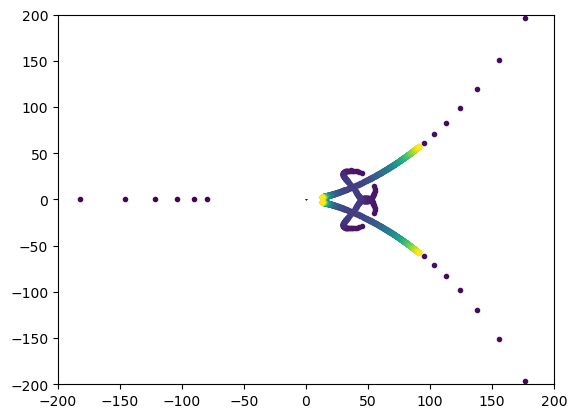

In [33]:
for i in range(int(noCs/subSamp)-1):
    currCol = cmap(i/(noCs/subSamp))
    lam1 = -DilRate/2 - np.sqrt((DilRate**2)/4 + eigsGLV[i*subSamp,0])
    lam2 = -DilRate/2 + np.sqrt((DilRate**2)/4 + eigsGLV[i*subSamp,0])
    lam3 = -DilRate/2 - np.sqrt((DilRate**2)/4 + eigsGLV[i*subSamp,1])
    lam4 = -DilRate/2 + np.sqrt((DilRate**2)/4 + eigsGLV[i*subSamp,1])
    dilEst1 = lam1 - (Vmax*0.04)/((DilRate+lam1)*(DilRate+2*lam1))
    dilEst2 = lam2 - (Vmax*0.04)/((DilRate+lam2)*(DilRate+2*lam2))
    dilEst3 = lam3 - (Vmax*0.04)/((DilRate+lam3)*(DilRate+2*lam3))
    dilEst4 = lam4 - (Vmax*0.04)/((DilRate+lam4)*(DilRate+2*lam4))
    plt.plot(np.real(dilEst1),np.imag(dilEst1),'.',color=currCol)
    plt.plot(np.real(dilEst2),np.imag(dilEst2),'.',color=currCol)
    plt.plot(np.real(dilEst3),np.imag(dilEst3),'.',color=currCol)
    plt.plot(np.real(dilEst4),np.imag(dilEst4),'.',color=currCol)

plt.plot([0,0],[-1,1],'k',lw=0.5)
plt.plot([-1,1],[0,0],'k',lw=0.5)
plt.xlim([-200,200])
plt.ylim([-200,200])

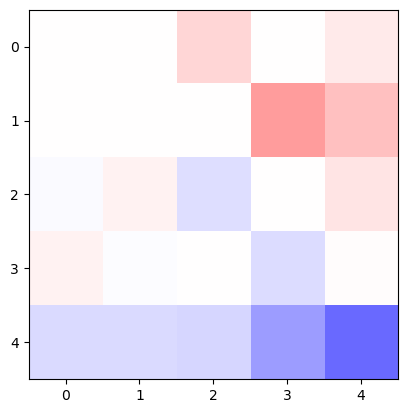

In [91]:
#Visualise Jacobian for different leakage rates
sliceInd = 200
Cs = np.array([[0,leakages[sliceInd],-1],[0.05,0,-1]])
EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

jac = constructJacobian(resList[sliceInd,:],abunds[sliceInd,:],EOparams,DilRate)
plt.imshow(jac,cmap='bwr',vmin=-0.1,vmax=0.1)
#[eigVals,eigVecs] = np.linalg.eig(jac)
#print(eigVecs)

[[ 0.          0.          0.01723823  0.          0.00796483]
 [ 0.          0.          0.          0.03865447  0.02330746]
 [-0.00200024  0.00486001 -0.01344765  0.          0.00973346]
 [ 0.00443923 -0.00100009  0.         -0.01386545  0.00120461]
 [-0.01444042 -0.0148609  -0.01723823 -0.03865447 -0.05613406]]
[-0.0404586 +0.j         -0.00633471+0.01009013j -0.00633471-0.01009013j
 -0.01000136+0.j         -0.02031776+0.j        ]
[0.23264565 0.16056631 0.22470315]
[0.51760376 0.69178216]


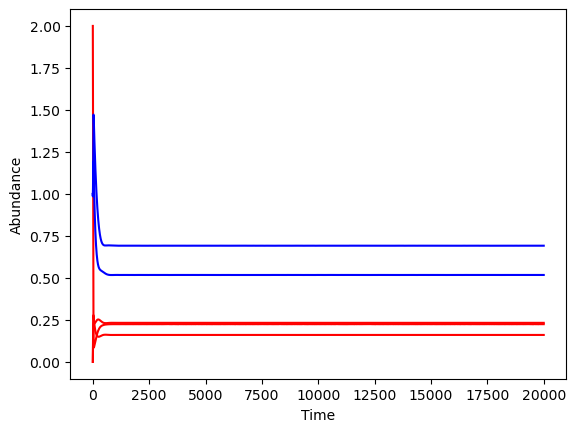

In [247]:
Cs = np.array([[0,0.1,-1],[0.05,0,-1]])
EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}
    
chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
chemSim.set_timeSettings(tSpan = [0,20000], dt=1)
chemSim.set_dilSettings(D=DilRate,transT=0.1)
chemSim.set_instInteract(instInteract)
chemSim.set_intrinsicGR(intrinsicGR)
chemSim.simEOmodel('Chemostat')

chemSim.plotSolutionTimecourse()

chemSim.rStar = chemSim.resTimeseries[:,-1]
chemSim.xStar = chemSim.specTimeseries[:,-1]
A = chemSim.assembleIntMat(chemSim.rStar)
mu = chemSim.assembleGRvec(chemSim.rStar)

jac = constructJacobian(chemSim.rStar,chemSim.xStar,EOparams,DilRate)
[eigVals,eigVecs] = np.linalg.eig(jac)

print(jac)
print(eigVals)
print(chemSim.rStar)
print(chemSim.xStar)

[[-2.88823136e-04 -6.68207169e-05]
 [-2.38475699e-04 -5.56573866e-04]]
[0.0001957  0.00050841]
EigResult(eigenvalues=array([-0.00012735, -0.00040717]), eigenvectors=array([[ 0.84218105,  0.13303255],
       [-0.53919484,  0.99111167]]))


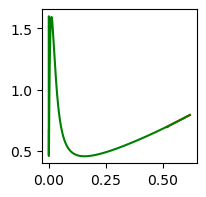

In [277]:
#Simulate aEO equation assuming static parameters (not dependent on resources).
def gLVaccel(t, y, A, mu):
    noSpec = int(len(y)/2)
    x = y[:noSpec]
    dx = y[noSpec:]
    
    GLVbit = mu + np.sum(np.matmul(np.diag(x),A),axis=0)
    
    ddx = np.multiply(GLVbit,x) + np.divide(np.multiply(dx,dx),x)
    return np.concatenate((dx,ddx), axis=0)

def simGLVaccel(EOparams,sysParams,x0,dx0):
    tMax = 2000
    dt = 0.1
    tSteps = np.arange(0,tMax,dt)    
    
    solution = solve_ivp(fun=gLVaccel,t_span=[0,tMax],y0=np.concatenate((x0,dx0),axis=0),args=(A, mu),t_eval=tSteps)
    return solution.y

dX0 = chemSim.xStar + np.array([0.1,0.1])#,0.1,0.2]);#Perturbed starting abundances
ddX0 = - np.array([0.01,0.01])

GLVeoAccel = simGLVaccel(A, mu,dX0,ddX0)

chemSimPeturb = EOsim(impactFunc,sensFunc,EOparams,sysParams,dX0,chemSim.rStar)
chemSimPeturb.set_timeSettings(tSpan = [0,2000], dt=1)
chemSimPeturb.set_dilSettings(D=DilRate,transT=0.1)
chemSimPeturb.set_instInteract(instInteract)
chemSimPeturb.set_intrinsicGR(intrinsicGR)
chemSimPeturb.simEOmodel('Chemostat')

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(2, 2)

print(A)
print(mu)
print(np.linalg.eig(np.matmul(np.diag(chemSim.xStar),A)))

plt.plot(chemSimPeturb.specTimeseries[0,:],chemSimPeturb.specTimeseries[1,:],'r')
plt.plot(GLVeoAccel[0,:],GLVeoAccel[1,:],'g')